<a href="https://colab.research.google.com/github/fatimashahid0111-boop/eeg-seizure-classification/blob/main/src/eeg_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------
# Preprocessing for Epileptic Seizure Recognition
# ---------------------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("/content/Epileptic Seizure Recognition.csv")

# Remove unnecessary index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# -----------------------------
# Separate Features and Target
# -----------------------------
X = df.drop(columns=["y"])  # features (EEG signals)
y = df["y"]
# Remove index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
# Select only numeric features
X = df.select_dtypes(include=['int64', 'float64'])
# Calculate IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))
# Count number of outliers
print("Number of outliers in each numeric feature:")
print(outliers.sum())
# Rows containing outliers
outlier_rows = df[outliers.any(axis=1)]
print("Total rows with outliers:", len(outlier_rows))

# Remove outliers
df_clean = df[~outliers.any(axis=1)]
print("Original dataset shape:", df.shape)
print("Dataset after removing outliers:", df_clean.shape)
#Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_standardized = scaler.fit_transform(X)

print(X_standardized[:5])

Number of outliers in each numeric feature:
X1      1292
X2      1272
X3      1283
X4      1272
X5      1272
        ... 
X175    1236
X176    1267
X177    1263
X178    1290
y          0
Length: 179, dtype: int64
Total rows with outliers: 4381
Original dataset shape: (11500, 180)
Dataset after removing outliers: (7119, 180)
[[ 8.85051341e-01  1.20992878e+00  1.46276429e+00  1.43953939e+00
   1.24236591e+00  8.18262328e-01  3.80910294e-01 -1.42671027e-02
  -1.63195713e-01 -1.98414816e-01 -2.60028461e-02  2.54644954e-01
   4.28241945e-01  7.09782837e-01  9.33053825e-01  1.01281797e+00
   8.12727143e-01  3.50155691e-01 -2.49225853e-01 -7.05658550e-01
  -8.08547134e-01 -7.22727232e-01 -5.67519141e-01 -2.59736709e-01
   1.03934663e-01  2.71302468e-01  1.76712698e-01  3.20856406e-01
   4.19589276e-01  3.16132342e-01  1.18596112e-01 -7.82582871e-02
  -3.37136811e-01 -5.58013947e-01 -7.77606192e-01 -7.89869077e-01
  -6.74368828e-01 -6.47805620e-01 -3.78824705e-01 -3.75739216e-02
   1.98299694e

In [ ]:
# data splitting
from sklearn.model_selection import train_test_split

# X = features
# y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (9200, 179)
Testing data shape: (2300, 179)


In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Apply PCA
# -----------------------------
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Training data after PCA:", X_train_pca.shape)
print("Testing data after PCA:", X_test_pca.shape)

Training data after PCA: (9200, 40)
Testing data after PCA: (2300, 40)


(9200, 179)
(2300, 179)
SVM RBF Accuracy on PCA data: 0.9948

Classification Report:
               precision    recall  f1-score   support

           1       0.98      1.00      0.99       460
           2       1.00      0.98      0.99       460
           3       1.00      1.00      1.00       460
           4       1.00      1.00      1.00       460
           5       1.00      1.00      1.00       460

    accuracy                           0.99      2300
   macro avg       0.99      0.99      0.99      2300
weighted avg       0.99      0.99      0.99      2300

Confusion Matrix:
 [[458   2   0   0   0]
 [  8 452   0   0   0]
 [  2   0 458   0   0]
 [  0   0   0 460   0]
 [  0   0   0   0 460]]


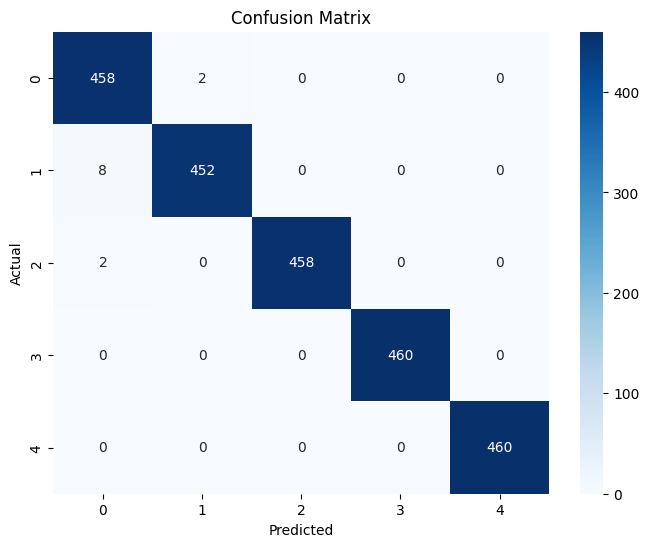

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm_model.fit(X_train, y_train)
print(X_train.shape)
print(X_test.shape)
# Predict on test data
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM RBF Accuracy on PCA data: {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True   # 🔥 REQUIRED for ROC
)

svm_model.fit(X_train, y_train)

SVC(C=10, class_weight='balanced', probability=True)

In [ ]:
y_score = svm_model.predict_proba(X_test)

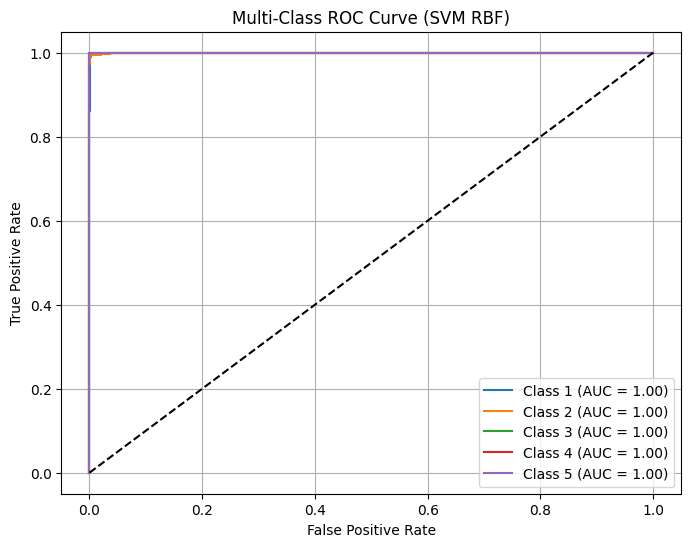

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to binary format
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probability predictions
y_score = svm_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (SVM RBF)")
plt.legend()
plt.grid()
plt.show()

In [ ]:

# ---------------------------------------------
# Preprocessing for Epileptic Seizure Recognition
# ---------------------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("/content/Epileptic Seizure Recognition.csv")

# Remove unnecessary index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# -----------------------------
# Separate Features and Target
# -----------------------------
X = df.drop(columns=["y"])  # features (EEG signals)
y = df["y"]
# Remove index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
# Select only numeric features
X = df.select_dtypes(include=['int64', 'float64'])
print(X.shape)
print(y.shape)

(11500, 179)
(11500,)


In [ ]:
# data splitting
from sklearn.model_selection import train_test_split

# X = features
# y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (9200, 179)
Testing data shape: (2300, 179)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# ---------------------------------------------
# FEATURE SCALING (after outlier removal)
# ---------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------
# TRAIN SVM (RBF KERNEL)
# ---------------------------------------------
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced'
)

svm_model.fit(X_train_scaled, y_train_clean)

print("SVM training completed")

SVM training completed


Test Accuracy: 0.7352173913043478

Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       460
           2       0.96      0.83      0.89       460
           3       0.95      0.88      0.92       460
           4       0.44      0.98      0.61       460
           5       0.99      0.98      0.99       460

    accuracy                           0.74      2300
   macro avg       0.67      0.74      0.68      2300
weighted avg       0.67      0.74      0.68      2300


Confusion Matrix:

[[  0   2   0 458   0]
 [  0 380  16  64   0]
 [  0  12 407  41   0]
 [  0   0   4 452   4]
 [  0   0   0   8 452]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


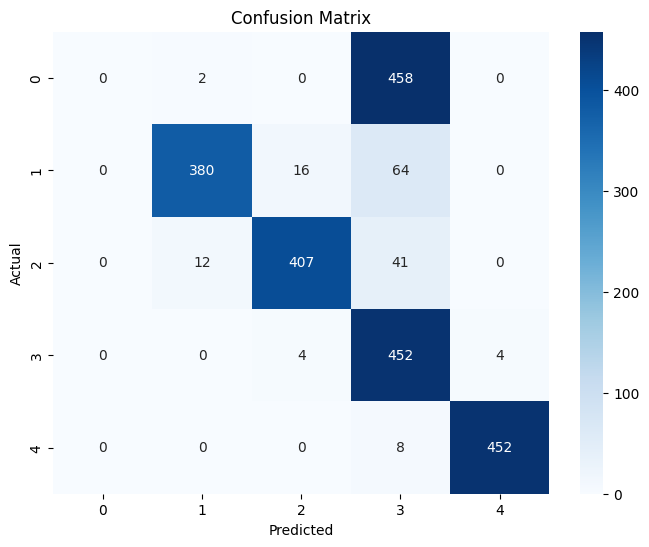

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
probability=True

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True
)

svm_model.fit(X_train_scaled, y_train_clean)

SVC(C=10, class_weight='balanced', probability=True)

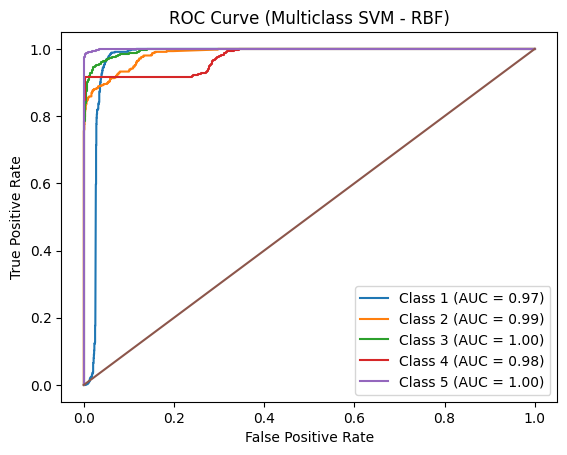

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_score = svm_model.predict_proba(X_test_scaled)

# Classes
classes = np.unique(y_test)

# Binarize output
y_test_bin = label_binarize(y_test, classes=classes)

# ROC storage
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass SVM - RBF)")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# -----------------------------
# Separate features and target
# -----------------------------
X = df.drop("y", axis=1)
y = df["y"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% test data
    random_state=42,      # reproducibility
    stratify=y            # keeps class balance
)

# -----------------------------
# Check shapes
# -----------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9200, 179)
X_test shape: (2300, 179)
y_train shape: (9200,)
y_test shape: (2300,)


In [ ]:
import numpy as np

# copy to avoid modifying original
X_train_clean = X_train.copy()
y_train_clean = y_train.copy()

# -----------------------------
# IQR calculation (ONLY on train)
# -----------------------------
Q1 = X_train_clean.quantile(0.25)
Q3 = X_train_clean.quantile(0.75)
IQR = Q3 - Q1

# outlier mask
mask = ~((X_train_clean < (Q1 - 1.5 * IQR)) | (X_train_clean > (Q3 + 1.5 * IQR))).any(axis=1)

# apply removal only on train
X_train_clean = X_train_clean[mask]
y_train_clean = y_train_clean[mask]

print("After outlier removal (train only):", X_train_clean.shape)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
import pandas as pd

# convert everything to numeric safely
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# remove rows with invalid values (train only for safety)
mask = ~X_train.isna().any(axis=1)
X_train = X_train[mask]
y_train = y_train[mask]

# also clean test (no leakage risk here)
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [ ]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

In [ ]:
# outlier mask
mask = ~((X_train_clean < (Q1 - 1.5 * IQR)) | (X_train_clean > (Q3 + 1.5 * IQR))).any(axis=1)

# apply removal only on train
X_train_clean = X_train_clean[mask]
y_train_clean = y_train_clean[mask]

print("After outlier removal (train only):", X_train_clean.shape)

After outlier removal (train only): (9200, 179)


In [ ]:
# Deep learning
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# Load dataset
data = pd.read_csv("/content/Epileptic Seizure Recognition.csv")

# Drop index column if present
data = data.drop(columns=['Unnamed'])

# Features and labels
X = data.drop("y", axis=1)
y = data["y"]

# Convert labels (1-5) to 0-4
y = y - 1

# Convert to numeric (safety)
X = X.apply(pd.to_numeric)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for LSTM (samples, time_steps, features)
# Here each sample has 178 time steps and 1 feature
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert labels to categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
print(data.shape)
print(data.head())
print(data.columns)

(11500, 180)
      Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   
3   X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   -81   
4   X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4     2   

   X172  X173  X174  X175  X176  X177  X178  y  
0   -31   -77  -103  -127  -116   -83   -51  4  
1   146   152   157   156   154   143   129  1  
2    48    19   -12   -30   -35   -35   -36  5  
3   -80   -77   -85   -77   -72   -69   -65  5  
4   -12   -32   -41   -65   -83   -89   -73  5  

[5 rows x 180 columns]
Index(['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object

In [ ]:
#Multilayer LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(178,1)))
model.add(Dropout(0.3))

# Second LSTM layer
model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.3))

# Third LSTM layer
model.add(LSTM(16))
model.add(Dropout(0.3))

# Fully connected layer
model.add(Dense(32, activation='relu'))

# Output layer (5 classes)
model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 178, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 178, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 178, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 178, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,157 (129.52 KB)

 Trainable params: 33,157 (129.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 31s 226ms/step - accuracy: 0.3530 - loss: 1.3816 - val_accuracy: 0.4092 - val_loss: 1.2104
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 222ms/step - accuracy: 0.3777 - loss: 1.2497 - val_accuracy: 0.4370 - val_loss: 1.1878
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 237ms/step - accuracy: 0.3986 - loss: 1.1961 - val_accuracy: 0.4277 - val_loss: 1.1586
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 217ms/step - accuracy: 0.4077 - loss: 1.1785 - val_accuracy: 0.4217 - val_loss: 1.2066
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - accuracy: 0.4140 - loss: 1.1978 - val_accuracy: 0.4457 - val_loss: 1.1736
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 224ms/step - accuracy: 0.4257 - loss: 1.1817 - val_accuracy: 0.4397 - val_loss: 1.1579
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.4251 - loss: 1.1770 - val_accuracy: 0.4467 - val_loss: 1.1614
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.4338 - loss: 1

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5791 - loss: 0.8789
Test Accuracy: 0.5791304111480713


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# =========================================================
# STEP 1: Get predictions from model
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# STEP 2: Convert predictions to class labels
# (IMPORTANT FIX for your error)
# =========================================================
if len(y_pred.shape) > 1:
    y_pred = np.argmax(y_pred, axis=1)

# =========================================================
# STEP 3: Fix y_test format (if one-hot encoded)
# =========================================================
if len(y_test.shape) > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

# =========================================================
# STEP 4: Confusion Matrix
# =========================================================
cm = confusion_matrix(y_test_labels, y_pred)

# =========================================================
# STEP 5: Plot Confusion Matrix
# =========================================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================================
# STEP 6: Classification Report
# =========================================================
print("Classification Report:\n")
print(classification_report(y_test_labels, y_pred))

# =========================================================
# STEP 7: Accuracy (optional)
# =========================================================
print("Accuracy:", accuracy_score(y_test_labels, y_pred))

NameError: name 'model' is not defined

In [ ]:
#ROC curve
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from itertools import cycle

In [ ]:
y_score = model.predict(X_test)   # keep probabilities (DO NOT use argmax)

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step


In [ ]:
# if y_test is one-hot encoded
if len(y_test.shape) > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

In [ ]:
n_classes = len(np.unique(y_test_labels))

In [ ]:
y_test_bin = label_binarize(y_test_labels, classes=np.arange(n_classes))

In [ ]:
y_score = model.predict(X_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step


In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

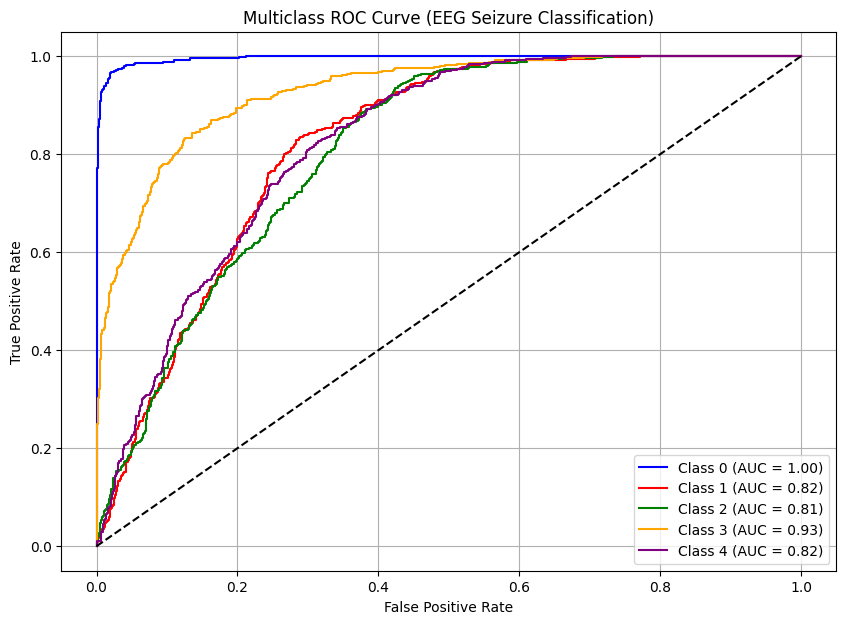

In [ ]:
plt.figure(figsize=(10, 7))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (EEG Seizure Classification)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Multilyer LSTM + Attention Layer
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Layer
from tensorflow.keras import backend as K

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight",
                                 shape=(input_shape[-1], 1),
                                 initializer="random_normal")
        self.b = self.add_weight(name="att_bias",
                                 shape=(input_shape[1], 1),
                                 initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.squeeze(e, axis=-1)
        alpha = K.softmax(e)
        alpha = K.expand_dims(alpha, axis=-1)
        output = x * alpha
        return K.sum(output, axis=1)

In [ ]:
inputs = Input(shape=(X_train.shape[1], 1))

lstm_out = LSTM(128, return_sequences=True)(inputs)
lstm_out = Dropout(0.3)(lstm_out)

lstm_out = LSTM(64, return_sequences=True)(lstm_out)

attention_out = AttentionLayer()(lstm_out)

dense1 = Dense(64, activation='relu')(attention_out)
dense1 = Dropout(0.3)(dense1)

outputs = Dense(5, activation='softmax')(dense1)
num_classes = len(np.unique(y_train))
outputs = Dense(num_classes, activation='softmax')(dense1)
model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # IMPORTANT for multiclass
    metrics=['accuracy']
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 178, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 178, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 178, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 178, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │           242 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,500 (470.70 KB)

 Trainable params: 120,500 (470.70 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
inputs = Input(shape=(X_train.shape[1], 1))

x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.3)(x)

x = LSTM(64, return_sequences=True)(x)

x = AttentionLayer()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

In [ ]:
print("Raw y_train shape:", y_train.shape)
print("First sample:", y_train[0])

Raw y_train shape: (9200, 5)
First sample: [1. 0. 0. 0. 0.]


In [ ]:
num_classes = y_train.shape[1]
print("Number of classes:", num_classes)

Number of classes: 5


In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

In [ ]:
num_classes = y_train.shape[1]
print("Number of classes:", num_classes)

Number of classes: 5


In [ ]:
inputs = Input(shape=(X_train.shape[1], 1))

x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.3)(x)

x = LSTM(64, return_sequences=True)(x)

x = AttentionLayer()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(model.output_shape)
print(y_train.shape)

(None, 5)
(9200, 5)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 99s 330ms/step - accuracy: 0.4082 - loss: 1.2200 - val_accuracy: 0.4670 - val_loss: 1.1036
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 93s 324ms/step - accuracy: 0.5161 - loss: 1.0387 - val_accuracy: 0.6348 - val_loss: 0.7708
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.6533 - loss: 0.7378 - val_accuracy: 0.6778 - val_loss: 0.6682
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 97s 336ms/step - accuracy: 0.6835 - loss: 0.6646 - val_accuracy: 0.7074 - val_loss: 0.5931
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 141s 333ms/step - accuracy: 0.7149 - loss: 0.6093 - val_accuracy: 0.7200 - val_loss: 0.5650
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 93s 323ms/step - accuracy: 0.7177 - loss: 0.5865 - val_accuracy: 0.7035 - val_loss: 0.6126
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 98s 340ms/step - accuracy: 0.7239 - loss: 0.5848 - val_accuracy: 0.7170 - val_loss: 0.5667
Epoch 8/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 97s 337ms/step - accuracy: 0.7268 - loss:

In [ ]:
import numpy as np

y_pred_prob = model.predict(X_test)

# convert probabilities → class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       460
           1       0.68      0.60      0.64       460
           2       0.64      0.61      0.63       460
           3       0.83      0.80      0.81       460
           4       0.73      0.86      0.79       460

    accuracy                           0.77      2300
   macro avg       0.77      0.77      0.77      2300
weighted avg       0.77      0.77      0.77      2300



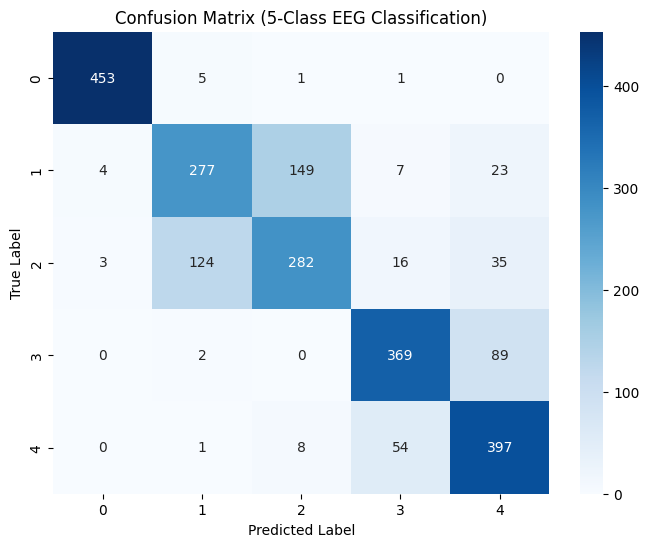

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (5-Class EEG Classification)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

# Test accuracy
accuracy = accuracy_score(y_true, y_pred)
print("\nTest Accuracy:", accuracy)

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       460
           1       0.68      0.60      0.64       460
           2       0.64      0.61      0.63       460
           3       0.83      0.80      0.81       460
           4       0.73      0.86      0.79       460

    accuracy                           0.77      2300
   macro avg       0.77      0.77      0.77      2300
weighted avg       0.77      0.77      0.77      2300


Test Accuracy: 0.7730434782608696


In [ ]:
#BILSTM + CNN 1D
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

input_layer = Input(shape=(178,1))

# CNN feature extractor
x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=128, kernel_size=3, activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# BiLSTM
x = Bidirectional(LSTM(64, return_sequences=False))(x)

# Fully connected
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

# Multiclass output (5 classes)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 178, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 176, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 176, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 88, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,125 (520.02 KB)

 Trainable params: 132,741 (518.52 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
 67/115 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.4589 - loss: 1.2612

KeyboardInterrupt: 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6987 - loss: 0.9898
Test Accuracy: 0.6986956596374512


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)

# convert one-hot to labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Test Accuracy: 0.6986956596374512

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       460
           1       0.56      0.26      0.36       460
           2       0.50      0.95      0.66       460
           3       0.98      0.58      0.73       460
           4       0.68      0.73      0.70       460

    accuracy                           0.70      2300
   macro avg       0.74      0.70      0.69      2300
weighted avg       0.74      0.70      0.69      2300



In [ ]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.6175 - loss: 0.8685 - val_accuracy: 0.4886 - val_loss: 1.1358
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.6621 - loss: 0.7232 - val_accuracy: 0.5875 - val_loss: 0.9037
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.6852 - loss: 0.6693 - val_accuracy: 0.6152 - val_loss: 0.7981
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.7136 - loss: 0.6184 - val_accuracy: 0.6332 - val_loss: 0.7280
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.7113 - loss: 0.6055 - val_accuracy: 0.6728 - val_loss: 0.6412
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.7341 - loss: 0.5687 - val_accuracy: 0.7332 - val_loss: 0.5215
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.7448 - loss: 0.5419 - val_accuracy: 0.7283 - val_loss: 0.5396
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - accuracy: 0.7607 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7752 - loss: 0.4658
Test Accuracy: 0.7752174139022827


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)

# convert one-hot to labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Test Accuracy: 0.7752174139022827

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       460
           1       0.73      0.38      0.50       460
           2       0.57      0.88      0.69       460
           3       0.92      0.79      0.85       460
           4       0.78      0.84      0.81       460

    accuracy                           0.78      2300
   macro avg       0.80      0.78      0.77      2300
weighted avg       0.80      0.78      0.77      2300



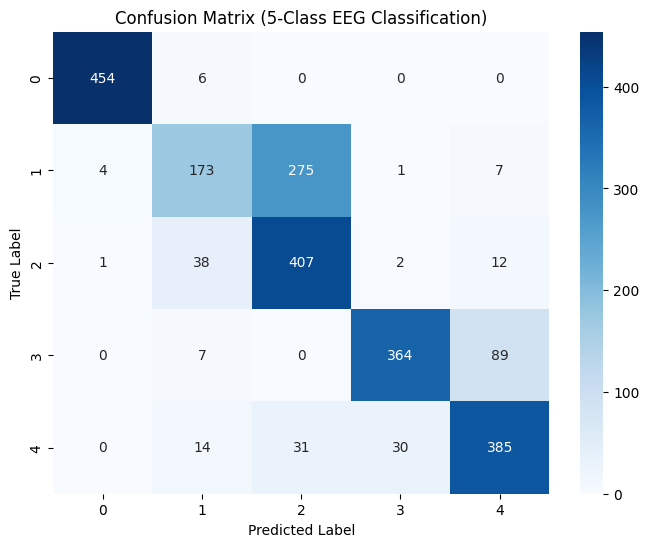

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (5-Class EEG Classification)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Give weights to classes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_true)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_true
)

class_weights = dict(enumerate(class_weights))

In [ ]:
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.7612 - loss: 0.5130 - val_accuracy: 0.6391 - val_loss: 0.7981
Epoch 2/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.7752 - loss: 0.4863 - val_accuracy: 0.7835 - val_loss: 0.4343
Epoch 3/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.7786 - loss: 0.4690 - val_accuracy: 0.7257 - val_loss: 0.6040
Epoch 4/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.7849 - loss: 0.4553 - val_accuracy: 0.7378 - val_loss: 0.6780
Epoch 5/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.7849 - loss: 0.4565 - val_accuracy: 0.7630 - val_loss: 0.4912
Epoch 6/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 153ms/step - accuracy: 0.8036 - loss: 0.4220 - val_accuracy: 0.7635 - val_loss: 0.5445
Epoch 7/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.8148 - loss: 0.4084 - val_accuracy: 0.7617 - val_loss: 0.5114
Epoch 8/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.8159 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8239 - loss: 0.5516
Test Accuracy: 0.823913037776947


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)

# convert one-hot to labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Test Accuracy: 0.823913037776947

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       460
           1       0.79      0.62      0.69       460
           2       0.67      0.82      0.74       460
           3       0.97      0.76      0.85       460
           4       0.77      0.94      0.85       460

    accuracy                           0.82      2300
   macro avg       0.84      0.82      0.82      2300
weighted avg       0.84      0.82      0.82      2300



In [ ]:
x = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)

x = Conv1D(128, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv1D(256, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2)(x)

In [ ]:
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(32, return_sequences=False))(x)

In [ ]:
from tensorflow.keras.layers import Dense, Multiply, Permute, Lambda
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Flatten, Dense, Activation, RepeatVector, Permute, Multiply, Lambda
attention = Dense(1, activation='tanh')(x)
attention = Flatten()(attention)
attention = Activation('softmax')(attention)
attention = RepeatVector(64)(attention)
attention = Permute([2,1])(attention)

x = Multiply()([x, attention])
x = Lambda(lambda xin: K.sum(xin, axis=1))(x)

In [ ]:
# Change parametes
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,          # allow enough learning time
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 30s 145ms/step - accuracy: 0.9655 - loss: 0.0922 - val_accuracy: 0.8152 - val_loss: 0.7411
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.9689 - loss: 0.0795 - val_accuracy: 0.7287 - val_loss: 1.5860
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9683 - loss: 0.0808 - val_accuracy: 0.7757 - val_loss: 1.1005
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.9698 - loss: 0.0805 - val_accuracy: 0.8183 - val_loss: 0.8330
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.9710 - loss: 0.0784 - val_accuracy: 0.8296 - val_loss: 0.7699
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.9767 - loss: 0.0623 - val_accuracy: 0.7561 - val_loss: 1.4136


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.8152 - loss: 0.7411
Test Accuracy: 0.8152173757553101


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)

# convert one-hot to labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step
Test Accuracy: 0.8152173757553101

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       460
           1       0.71      0.64      0.67       460
           2       0.65      0.80      0.72       460
           3       0.94      0.82      0.88       460
           4       0.82      0.84      0.83       460

    accuracy                           0.82      2300
   macro avg       0.82      0.82      0.82      2300
weighted avg       0.82      0.82      0.82      2300



In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

input_layer = Input(shape=(178, 1))

# CNN BLOCK (stronger feature extraction)
x = Conv1D(64, 3, padding='same', activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

x = Conv1D(128, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

x = Conv1D(256, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

# BI-LSTM BLOCK (key upgrade)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
x = Bidirectional(LSTM(64, return_sequences=False, dropout=0.3))(x)

# DENSE CLASSIFIER
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(5, activation='softmax')(x)

model = Model(input_layer, output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 1/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 79s 455ms/step - accuracy: 0.5561 - loss: 0.9931 - val_accuracy: 0.2239 - val_loss: 2.3091 - learning_rate: 5.0000e-04
Epoch 2/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 99s 574ms/step - accuracy: 0.6434 - loss: 0.7570 - val_accuracy: 0.3670 - val_loss: 1.3086 - learning_rate: 5.0000e-04
Epoch 3/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 124s 450ms/step - accuracy: 0.6801 - loss: 0.6824 - val_accuracy: 0.4391 - val_loss: 1.1914 - learning_rate: 5.0000e-04
Epoch 4/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 78s 424ms/step - accuracy: 0.6877 - loss: 0.6502 - val_accuracy: 0.6026 - val_loss: 0.8335 - learning_rate: 5.0000e-04
Epoch 5/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 81s 422ms/step - accuracy: 0.7112 - loss: 0.6091 - val_accuracy: 0.5926 - val_loss: 0.8486 - learning_rate: 5.0000e-04
Epoch 6/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 61s 422ms/step - accuracy: 0.7226 - loss: 0.5712 - val_accuracy: 0.6891 - val_loss: 0.6144 - learning_rate: 5.0000e-04
Epoch 7/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 61s 4

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8604 - loss: 0.3261
Test Accuracy: 0.8604347705841064


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)

# convert one-hot to labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step
Test Accuracy: 0.8604347705841064

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       460
           1       0.77      0.71      0.74       460
           2       0.73      0.77      0.75       460
           3       0.92      0.93      0.93       460
           4       0.88      0.90      0.89       460

    accuracy                           0.86      2300
   macro avg       0.86      0.86      0.86      2300
weighted avg       0.86      0.86      0.86      2300



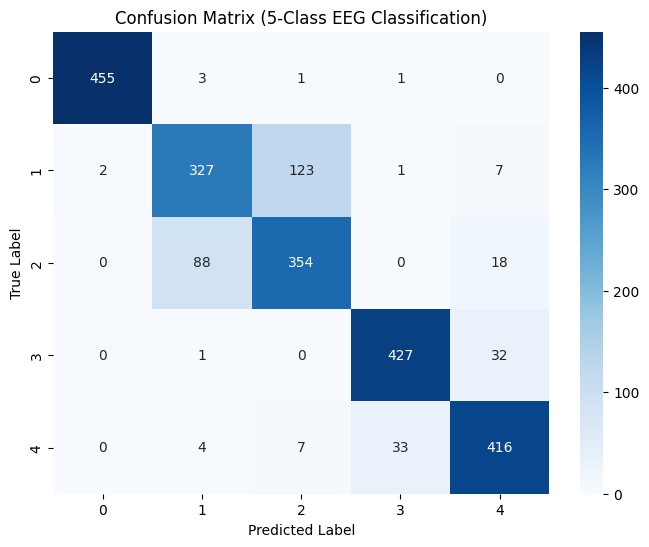

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (5-Class EEG Classification)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=320a6d0c4404ba7fab96dac405a689191c9653bfc245e72607431d447a7948ea
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
from lime import lime_tabular
import matplotlib.pyplot as plt

In [ ]:
# reshape training data
X_train_lime = X_train.reshape(X_train.shape[0], 178)
X_test_lime = X_test.reshape(X_test.shape[0], 178)

In [ ]:
def predict_fn(data):
    data = data.reshape(data.shape[0], 178, 1)
    return model.predict(data)

In [ ]:
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    mode='classification',
    feature_names=[f'F{i}' for i in range(178)],
    class_names=['Class0','Class1','Class2','Class3','Class4'],
    discretize_continuous=True
)

In [ ]:
i = 10   # sample index

exp = explainer.explain_instance(
    X_test_lime[i],
    predict_fn,
    num_features=10
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step


In [ ]:
exp.show_in_notebook(show_table=True)

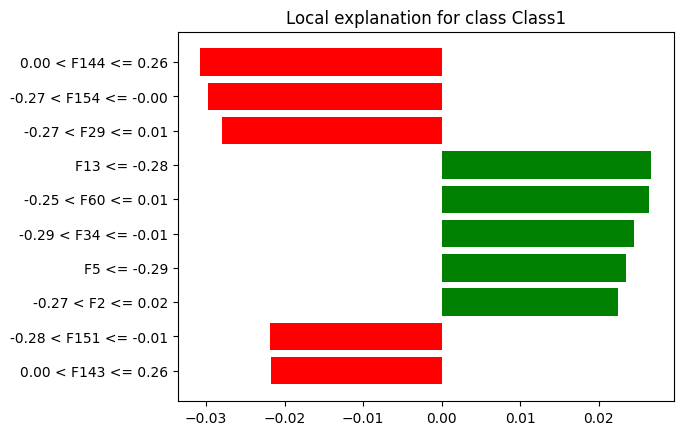

In [ ]:
exp.as_pyplot_figure()
plt.show()